# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import nltk
from sklearn.tree import DecisionTreeClassifier

In [3]:
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [4]:
df = pd.read_csv('tweet_sentiment_train.csv.zip')
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [6]:
print(f"Розмір датасету: {df.shape}\n")
print(f"Пропущені значення:\n{df.isnull().sum()}\n")
print(f"Загальна кількість пропусків: {df.isnull().sum().sum()}")

Розмір датасету: (27481, 4)

Пропущені значення:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

Загальна кількість пропусків: 2


In [7]:
# Видалення пропущених значень
df = df.dropna()
print(f"Розмір після видалення пропусків: {df.shape}")

Розмір після видалення пропусків: (27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [8]:
# Розподіл класів
print("Розподіл класів sentiment:")
print(df['sentiment'].value_counts())
print(f"\nВідсоткове співвідношення:")
print(df['sentiment'].value_counts(normalize=True).round(4) * 100)

Розподіл класів sentiment:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

Відсоткове співвідношення:
sentiment
neutral     40.45
positive    31.23
negative    28.32
Name: proportion, dtype: float64


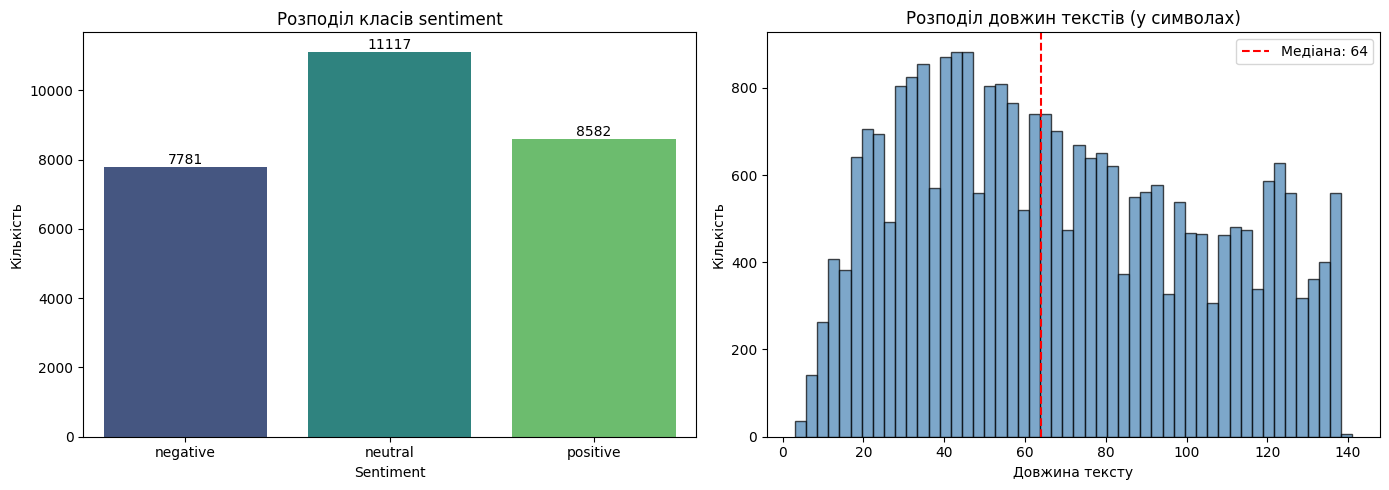

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барплот розподілу класів
sns.countplot(data=df, x='sentiment', order=['negative', 'neutral', 'positive'],
              palette='viridis', ax=axes[0])
axes[0].set_title('Розподіл класів sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Кількість')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

# Довжина текстів у символах
df['text_length'] = df['text'].str.len()
axes[1].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Розподіл довжин текстів (у символах)')
axes[1].set_xlabel('Довжина тексту')
axes[1].set_ylabel('Кількість')
axes[1].axvline(df['text_length'].median(), color='red', linestyle='--',
                label=f"Медіана: {df['text_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
print(f"Статистика довжин текстів:")
print(df['text_length'].describe().round(1))

Статистика довжин текстів:
count    27480.0
mean        68.3
std         35.6
min          3.0
25%         39.0
50%         64.0
75%         97.0
max        141.0
Name: text_length, dtype: float64


Аналіз показав, що найбільшу частку датасету складають нейтральні повідомлення (~40%), тоді як позитивні та негативні класи представлені більш рівномірно. Таким чином, набір даних є помірно незбалансованим. Більшість постів мають довжину до 100-120 символів (обмеження Twitter). Розподіл зміщений вправо, тобто найбільше коротких повідомлень. Медіана — 64 символи, середня довжина ~68 символів. Це типово для Twitter — короткі повідомлення. 75% постів мають довжину до 97 символів.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [11]:
# Препроцесинг тексту
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

# Для sentiment analysis залишаємо заперечення
negation_words = {'no', 'not', 'nor'}
stop_words = stop_words - negation_words

def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token.isalpha() and token not in stop_words
    ]
    return ' '.join(tokens)


df['text_clean'] = df['text'].apply(preprocess_text)

In [12]:
# Аналіз розміру словника для вибору max_features
temp_vectorizer = CountVectorizer()
temp_vectorizer.fit(df['text_clean'])

vocab_size = len(temp_vectorizer.vocabulary_)
print(f"Розмір повного словника: {vocab_size}")

Розмір повного словника: 17767


In [13]:
# Повний словник містить 17767 токенів, тому обмежуємо його до 10000 найбільш частотних слів, щоб зменшити шум і розмірність матриці
bow_vectorizer = CountVectorizer(max_features=10000)
X_bow = bow_vectorizer.fit_transform(df['text_clean'])

print(f"Розмір BoW матриці: {X_bow.shape}")
print(f"Кількість ненульових елементів: {X_bow.nnz}")

sparsity = 1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
print(f"Розрідженість: {sparsity:.4f}")

Розмір BoW матриці: (27480, 10000)
Кількість ненульових елементів: 176225
Розрідженість: 0.9994


Було виконано базову попередню обробку текстів: приведення до нижнього регістру, токенізацію, видалення stopwords та стемінг. Заперечення no/not/nor були залишені, оскільки вони можуть суттєво змінювати sentiment тексту.

Після очищення тексти були перетворені у числове представлення методом Bag of Words за допомогою CountVectorizer. Повний словник містив близько 17.7 тис. токенів, тому для зменшення розмірності було обрано max_features=10000. Отримана BoW-матриця має розмір 27480 × 10000 і є дуже розрідженою, що є типовою властивістю bag-of-words представлення текстових даних.

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [14]:
df = df.reset_index(drop=True)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

X_train_bow = X_bow[train_idx]
X_test_bow = X_bow[test_idx]

y_train = df.loc[train_idx, 'sentiment']
y_test = df.loc[test_idx, 'sentiment']

In [15]:
print(f"Train: {len(train_idx)}, Test: {len(test_idx)}\n")
print("Розподіл класів у train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nРозподіл класів у test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 21984, Test: 5496

Розподіл класів у train:
sentiment
neutral     0.405
positive    0.312
negative    0.283
Name: proportion, dtype: float64

Розподіл класів у test:
sentiment
neutral     0.404
positive    0.312
negative    0.283
Name: proportion, dtype: float64


In [16]:
# Порівняння кількох моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=50,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    y_pred = model.predict(X_test_bow)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1_weighted': f1}
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (weighted): {f1:.4f}")
    print(f"{'='*50}")

Logistic Regression
Accuracy: 0.6918
F1 (weighted): 0.6926
Random Forest
Accuracy: 0.6923
F1 (weighted): 0.6920
Decision Tree
Accuracy: 0.6690
F1 (weighted): 0.6650


In [17]:
# Обираємо найкращу модель
best_model_name = max(results, key=lambda x: results[x]['f1_weighted'])
print(f"Найкраща модель: {best_model_name}\n")

# Детальний звіт для найкращої моделі
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_bow)

print(f"Classification Report ({best_model_name}):")
print(classification_report(y_test, y_pred_best))

Найкраща модель: Logistic Regression

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    negative       0.71      0.64      0.67      1556
     neutral       0.63      0.72      0.67      2223
    positive       0.77      0.71      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.69      0.69      5496
weighted avg       0.70      0.69      0.69      5496



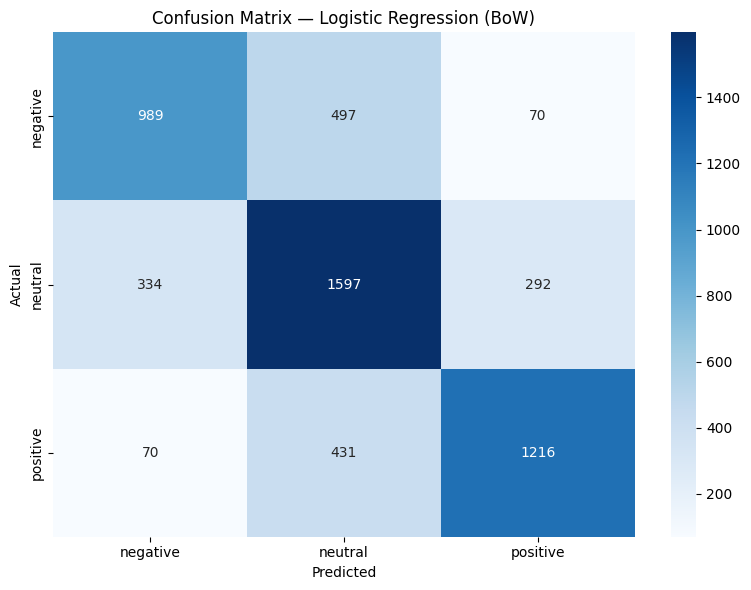

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name} (BoW)')
plt.tight_layout()
plt.show()

Було протестовано кілька моделей машинного навчання:
* Logistic Regression
* Random Forest
* Decision Tree

Найкращі результати показала модель Logistic Regression:
* Accuracy = 0.6918
* Weighted F1-score = 0.6926

Random Forest показав дуже близький результат, а Decision Tree виявився менш ефективним для цієї задачі. Це відповідає типовій поведінці моделей на sparse текстових даних, оскільки лінійні моделі часто краще працюють із Bag-of-Words представленням.

Аналіз Classification Report та Confusion Matrix показав, що модель найкраще визначає positive sentiment, тоді як найбільше помилок виникає між класами negative та neutral, а також positive та neutral. Це свідчить про те, що neutral тексти є найскладнішими для чіткого розділення.    

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [19]:
# Аналіз важливості слів для Logistic Regression (BoW)
lr_model = models['Logistic Regression']

feature_names = np.array(bow_vectorizer.get_feature_names_out())
classes = lr_model.classes_

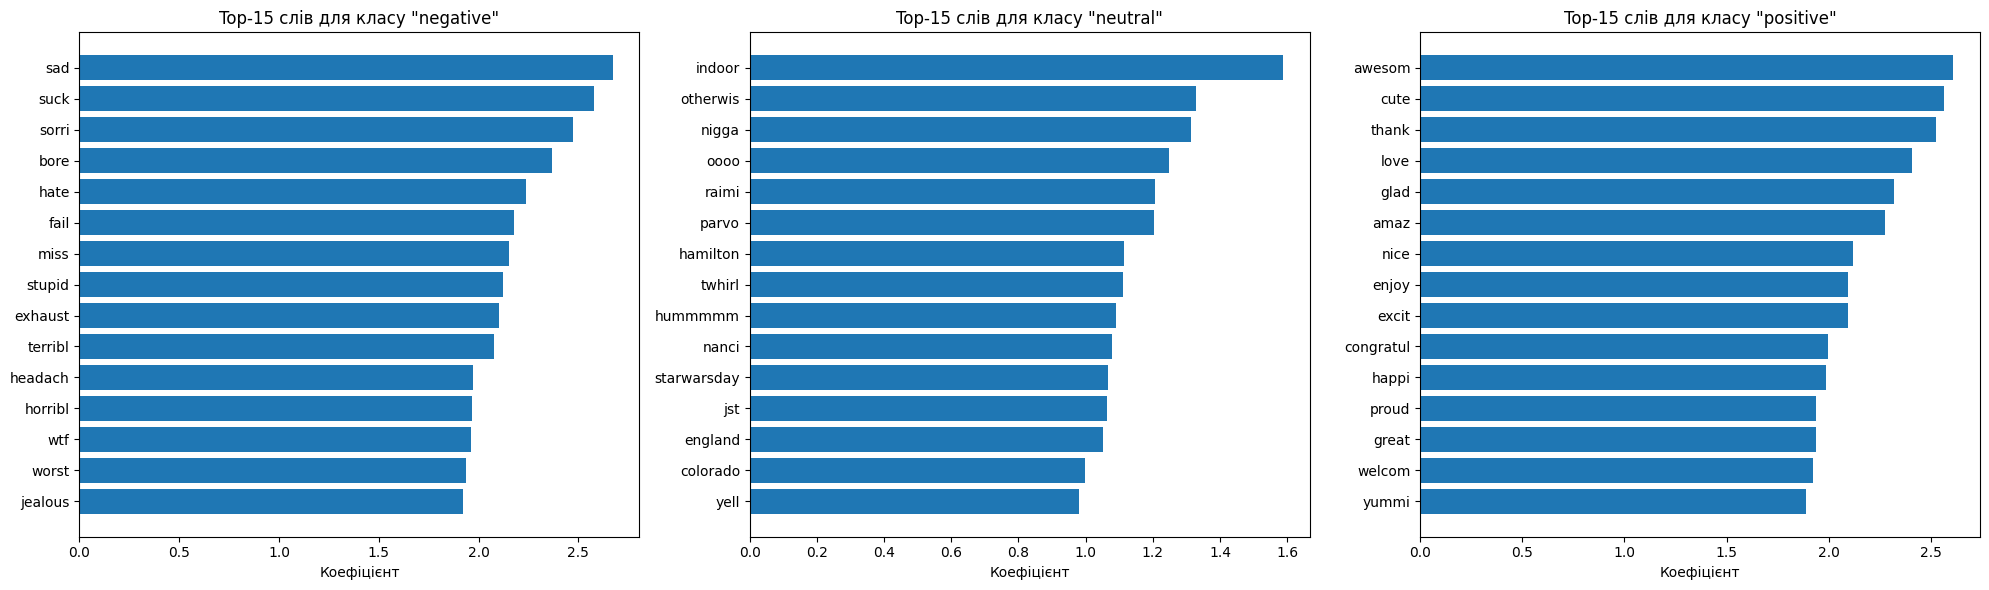

In [20]:
# Візуалізація топ-слів для кожного класу
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, cls in enumerate(classes):
    coefs = lr_model.coef_[idx]

    # Топ-15 найбільших позитивних коефіцієнтів
    top_idx = np.argsort(coefs)[-15:]
    top_words = feature_names[top_idx]
    top_values = coefs[top_idx]

    axes[idx].barh(top_words, top_values)
    axes[idx].set_title(f'Top-15 слів для класу "{cls}"')
    axes[idx].set_xlabel('Коефіцієнт')

plt.tight_layout()
plt.show()

In [21]:
for idx, cls in enumerate(classes):
    coefs = lr_model.coef_[idx]
    top_idx = np.argsort(coefs)[-10:][::-1]
    top_words_df = pd.DataFrame({
        'word': feature_names[top_idx],
        'coefficient': coefs[top_idx].round(4)
    })

    print(f'Top-10 найважливіших слів для класу "{cls}":')
    display(top_words_df)

Top-10 найважливіших слів для класу "negative":


,word,coefficient
0,sad,2.6729
1,suck,2.5799
2,sorri,2.4730
3,bore,2.3667
4,hate,2.2367
5,fail,2.1786
6,miss,2.1546
7,stupid,2.1217
8,exhaust,2.1043
9,terribl,2.0764


Top-10 найважливіших слів для класу "neutral":


,word,coefficient
0,indoor,1.5876
1,otherwis,1.3286
2,nigga,1.3124
3,oooo,1.2491
4,raimi,1.2078
5,parvo,1.2049
6,hamilton,1.1133
7,twhirl,1.1101
8,hummmmm,1.0901
9,nanci,1.0772


Top-10 найважливіших слів для класу "positive":


,word,coefficient
0,awesom,2.6094
1,cute,2.5637
2,thank,2.5234
3,love,2.4094
4,glad,2.3179
5,amaz,2.2772
6,nice,2.1206
7,enjoy,2.0933
8,excit,2.0920
9,congratul,1.9961


Було проведено аналіз найважливіших слів для моделі Logistic Regression, навченій на Bag-of-Words ознаках. Модель використовує коефіцієнти для визначення того, які слова найбільше впливають на належність тексту до певного класу sentiment.

Для негативного класу найбільш впливовими виявилися слова: `sad`, `suck`, `hate`, `fail`, `stupid`, `terribl`, що логічно відповідає негативному емоційному забарвленню.
Для позитивного класу модель виділила слова: `awesom`, `love`, `thank`, `glad`, `amaz`, `nice`, `enjoy`, які є дійсно позитивними індикаторами.

Для нейтрального класу найбільш важливими стали більш контекстні або менш емоційно забарвлені слова (`indoor`, `otherwis`, `hamilton`, `colorado` тощо). Це показує, що нейтральний sentiment визначати складніше, оскільки він не має настільки очевидних маркерів, як positive або negative.

Отримані результати виглядають логічними та підтверджують, що модель навчилася розпізнавати ключові слова, пов’язані з емоційною полярністю тексту.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [22]:
# TF-IDF векторизація з тим самим препроцесингом
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_tfidf = tfidf_vectorizer.fit_transform(df['text_clean'])

print(f"Розмір TF-IDF матриці: {X_tfidf.shape}")

Розмір TF-IDF матриці: (27480, 10000)


In [23]:
# Використовуємо ті ж самі індекси для train/test
X_train_tfidf = X_tfidf[df.index.get_indexer(train_idx)]
X_test_tfidf = X_tfidf[df.index.get_indexer(test_idx)]

print(f"Train: {X_train_tfidf.shape[0]}, Test: {X_test_tfidf.shape[0]}")

Train: 21984, Test: 5496


In [24]:
# Тренуємо Logistic Regression на TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf, average='weighted')

print(f"Logistic Regression (TF-IDF):")
print(f"Accuracy: {acc_tfidf:.4f}")
print(f"F1 (weighted): {f1_tfidf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf))

Logistic Regression (TF-IDF):
Accuracy: 0.6949
F1 (weighted): 0.6957

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.62      0.67      1556
     neutral       0.62      0.76      0.68      2223
    positive       0.79      0.68      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.72      0.69      0.70      5496
weighted avg       0.71      0.69      0.70      5496



In [25]:
# Порівняння BoW vs TF-IDF
print("Порівняння BoW vs TF-IDF (Logistic Regression):")
print(f"{'Метрика':<20} {'BoW':>10} {'TF-IDF':>10}")
print(f"{'Accuracy':<20} {results['Logistic Regression']['accuracy']:>10.4f} {acc_tfidf:>10.4f}")
print(f"{'F1 (weighted)':<20} {results['Logistic Regression']['f1_weighted']:>10.4f} {f1_tfidf:>10.4f}")

Порівняння BoW vs TF-IDF (Logistic Regression):
Метрика                     BoW     TF-IDF
Accuracy                 0.6918     0.6949
F1 (weighted)            0.6926     0.6957


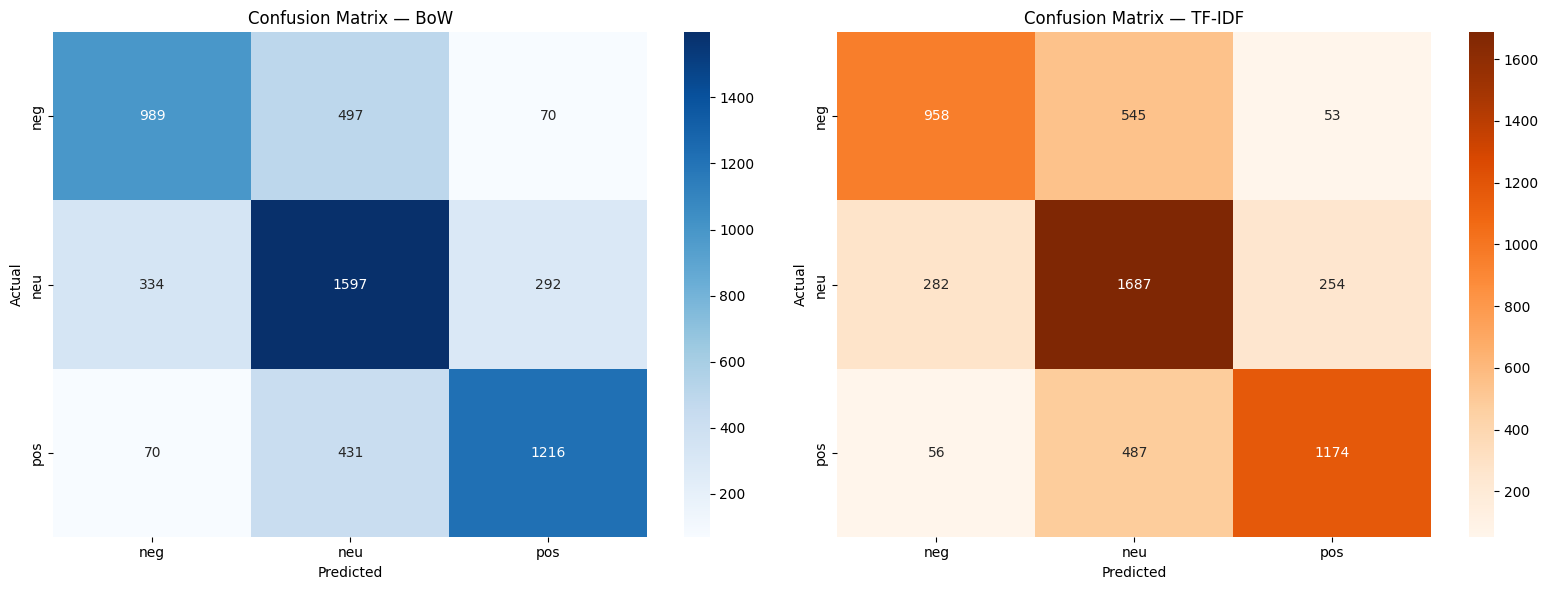

In [26]:
# Confusion matrix для TF-IDF
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=['negative', 'neutral', 'positive'])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BoW confusion matrix
cm_bow = confusion_matrix(y_test, models['Logistic Regression'].predict(X_test_bow),
                          labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg', 'neu', 'pos'],
            yticklabels=['neg', 'neu', 'pos'], ax=axes[0])
axes[0].set_title('Confusion Matrix — BoW')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# TF-IDF confusion matrix
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['neg', 'neu', 'pos'],
            yticklabels=['neg', 'neu', 'pos'], ax=axes[1])
axes[1].set_title('Confusion Matrix — TF-IDF')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

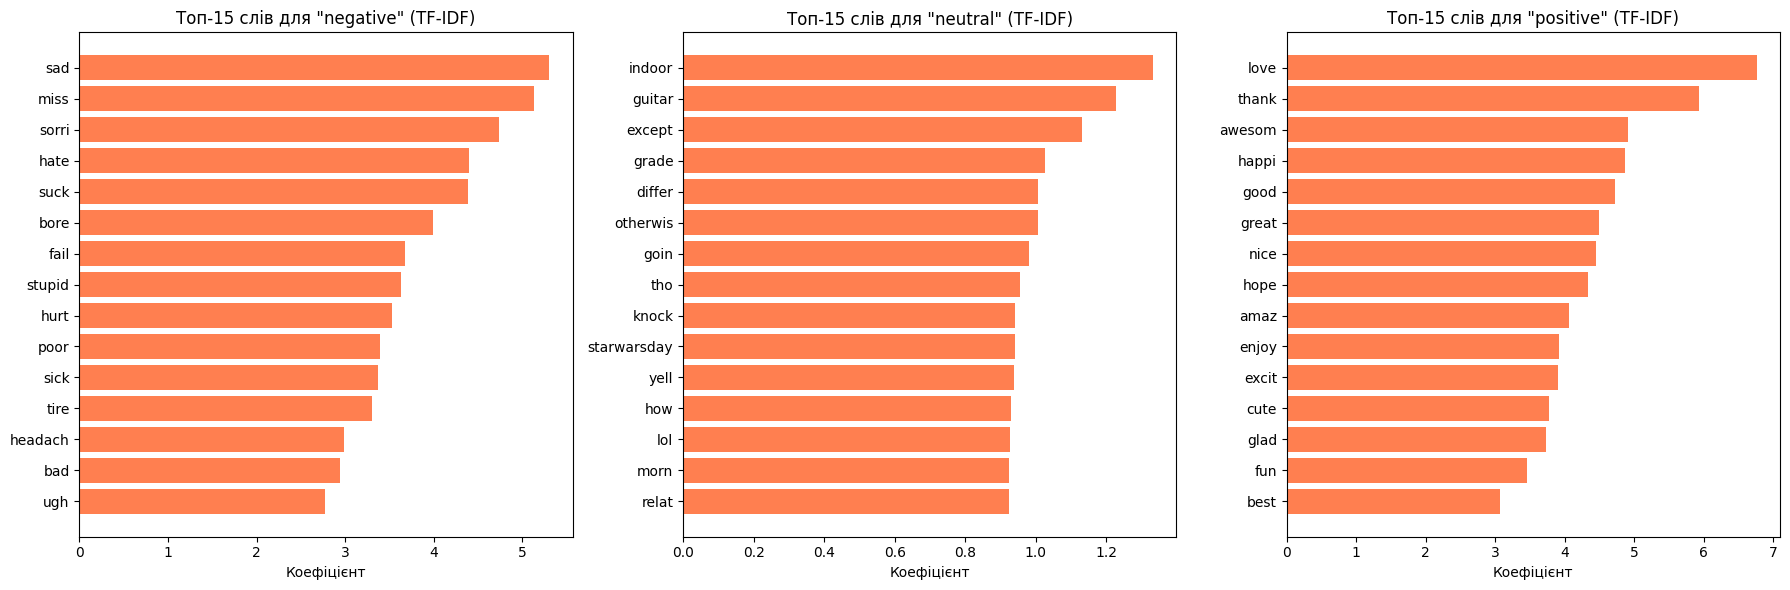

In [27]:
# Аналіз впливовості слів TF-IDF
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, cls in enumerate(lr_tfidf.classes_):
    coefs = lr_tfidf.coef_[idx]
    top_idx = np.argsort(coefs)[-15:]
    axes[idx].barh(range(15), coefs[top_idx], color='coral')
    axes[idx].set_yticks(range(15))
    axes[idx].set_yticklabels(tfidf_feature_names[top_idx])
    axes[idx].set_title(f'Топ-15 слів для "{cls}" (TF-IDF)')
    axes[idx].set_xlabel('Коефіцієнт')

plt.tight_layout()
plt.show()

In [28]:
# Порівняння топ-слів BoW vs TF-IDF
print("Порівняння топ-10 слів BoW vs TF-IDF:\n")
for cls_idx, cls in enumerate(classes):
    bow_coefs = lr_model.coef_[cls_idx]
    tfidf_coefs = lr_tfidf.coef_[cls_idx]

    bow_top = set(feature_names[np.argsort(bow_coefs)[-10:]])
    tfidf_top = set(tfidf_feature_names[np.argsort(tfidf_coefs)[-10:]])

    common = bow_top & tfidf_top
    print(f"--- {cls} ---")
    print(f"Спільних слів у топ-10: {len(common)} з 10")
    print(f"Спільні: {common}")
    print()

Порівняння топ-10 слів BoW vs TF-IDF:

--- negative ---
Спільних слів у топ-10: 8 з 10
Спільні: {'sorri', 'hate', 'bore', 'suck', 'stupid', 'fail', 'sad', 'miss'}

--- neutral ---
Спільних слів у топ-10: 2 з 10
Спільні: {'otherwis', 'indoor'}

--- positive ---
Спільних слів у топ-10: 6 з 10
Спільні: {'awesom', 'enjoy', 'love', 'nice', 'amaz', 'thank'}



Було виконано TF-IDF векторизацію текстів та натреновано модель Logistic Regression на тих самих train/test даних, що й у випадку Bag-of-Words. TF-IDF показав трохи кращі результати: accuracy зросла з 0.6918 до 0.6949, а weighted F1-score — з 0.6926 до 0.6957.

Порівняння confusion matrix показало, що TF-IDF краще класифікує neutral клас, хоча positive клас визначається трохи гірше, ніж у BoW. Основна проблема моделі залишилась незмінною — частина negative та positive повідомлень усе ще плутається з neutral.

Аналіз важливості слів показав, що для negative та positive класів найбільш впливові токени залишаються дуже схожими між BoW і TF-IDF. Для negative класу співпало 8 із 10 топ-слів (`sad`, `suck`, `hate`, `fail`, `miss` тощо), а для positive — 6 із 10 (`love`, `thank`, `awesom`, `amaz`, `nice`, `enjoy`). Для neutral класу збігів майже немає, що підтверджує, що нейтральний sentiment значно складніше описати стабільними ключовими словами.

Загалом TF-IDF показав трохи кращу якість та більш гнучко враховує важливість слів у текстах, тому для фінальної реалізації доцільніше використовувати саме TF-IDF векторизацію.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [29]:
# Аналіз помилок класифікації (TF-IDF)
df_test = df.loc[test_idx].copy()
df_test['predicted'] = y_pred_tfidf
df_test['correct'] = df_test['sentiment'] == df_test['predicted']

total_errors = (~df_test['correct']).sum()
print(f"Загальна кількість помилок: {total_errors} з {len(df_test)} ({total_errors/len(df_test)*100:.1f}%)")

Загальна кількість помилок: 1677 з 5496 (30.5%)


In [30]:
# Розподіл помилок по класах
print(f"Помилки по реальних класах:")
error_by_class = df_test[~df_test['correct']].groupby('sentiment').size()
total_by_class = df_test.groupby('sentiment').size()
for cls in ['negative', 'neutral', 'positive']:
    n_err = error_by_class.get(cls, 0)
    n_total = total_by_class[cls]
    print(f"{cls}: {n_err}/{n_total} ({n_err/n_total*100:.1f}%)")

Помилки по реальних класах:
negative: 598/1556 (38.4%)
neutral: 536/2223 (24.1%)
positive: 543/1717 (31.6%)


In [31]:
# Типові помилки — плутання між класами
print(f"Найчастіші типи плутанини:")
errors = df_test[~df_test['correct']]
confusion_pairs = errors.groupby(['sentiment', 'predicted']).size().sort_values(ascending=False)
print(confusion_pairs.head(6))

Найчастіші типи плутанини:
sentiment  predicted
negative   neutral      545
positive   neutral      487
neutral    negative     282
           positive     254
positive   negative      56
negative   positive      53
dtype: int64


In [32]:
# Приклади помилкових класифікацій
print("Приклади помилок (реальний → передбачений):\n")
for true_cls in ['negative', 'neutral', 'positive']:
    wrong = errors[errors['sentiment'] == true_cls].head(3)
    for _, row in wrong.iterrows():
        print(f"[{row['sentiment']} → {row['predicted']}]: {row['text'][:120]}")
    print()

Приклади помилок (реальний → передбачений):

[negative → neutral]: Reading and taking notes but undertanding none of it  ... HELP!
[negative → positive]:  Awww, *hugs* I wish I could help.
[negative → neutral]: 2 hours after teleconference. but can`t go back to sleep. got some work to do. sigh sigh

[neutral → negative]: Hoping that this will just heal on it`s own because anything I put on it just makes it worse. Owww
[neutral → negative]: shack idol today(: can`t wait. it`s gonna be funnn poor cameron. he fell ON A BAR in speech today. i felt so bad for him
[neutral → positive]:  **** Frat - that`s too bad...  Should be a good show (at least I`m hoping so) esp. since it`s in BK...

[positive → neutral]: wow this morning 8.15 hrs ding dong breakfastservice, was a surprise of Marjoleine, Guido and Dirk for mothersday.Mother
[positive → neutral]:  yum. Do you do home delivery
[positive → neutral]: Having a wonderful piece of cake for lunch - what else could I want???



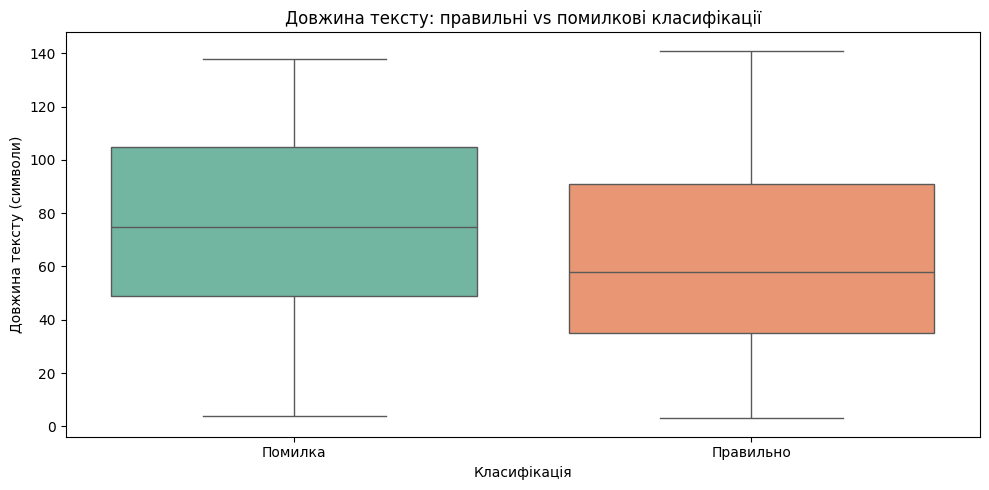


Середня довжина — правильні: 64.6
Середня довжина — помилкові: 76.5


In [33]:
# Аналіз довжини текстів — чи впливає довжина на помилки
fig, ax = plt.subplots(figsize=(10, 5))
df_test['text_length'] = df_test['text'].str.len()
sns.boxplot(data=df_test, x='correct', y='text_length', ax=ax, palette='Set2')
ax.set_xticklabels(['Помилка', 'Правильно'])
ax.set_xlabel('Класифікація')
ax.set_ylabel('Довжина тексту (символи)')
ax.set_title('Довжина тексту: правильні vs помилкові класифікації')
plt.tight_layout()
plt.show()

print(f"\nСередня довжина — правильні: {df_test[df_test['correct']]['text_length'].mean():.1f}")
print(f"Середня довжина — помилкові: {df_test[~df_test['correct']]['text_length'].mean():.1f}")

У результаті аналізу помилок було виявлено, що модель Logistic Regression з TF-IDF найчастіше плутає negative та positive тексти з neutral класом. Це свідчить про те, що модель погано працює зі складними або неоднозначними емоційними висловлюваннями.

Аналіз прикладів показав, що найбільше проблем виникає з:
- сарказмом і співчутливими фразами,
- текстами зі змішаними емоціями,
- довшими реченнями з кількома контекстами.

Також було помічено, що помилкові класифікації в середньому мають більшу довжину тексту, ніж правильні. Це може означати, що TF-IDF погано враховує контекст і порядок слів у складніших повідомленнях.

Для покращення якості моделі можна:
1. Використовувати n-gram (bigram/trigram) для кращого врахування контексту. Замість окремих слів враховувати словосполучення — це допоможе вловити вирази типу "not good", "no way", які змінюють сентимент.
2. Покращити preprocessing: обробку slang, emoji, скорочень та сарказму.
3. Спробувати більш сильні моделі для NLP, підібрати гіперпараметри або використати Transformer-моделі.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model